
## PARTE I – HS + FN + XAI (15/09/2025)

In [ ]:
import os, math, re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict, Optional, Union

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib

OUT_DIR = "./OUT_TFIDF_SVM"
os.makedirs(OUT_DIR, exist_ok=True)

print("numpy:", np.__version__, "| pandas:", pd.__version__)

numpy: 2.0.2 | pandas: 2.2.2


In [ ]:
CSV_FN = "Fakebr_Odio.csv"
CSV_HS = "HateBR_Fake.csv"

df_fn = pd.read_csv(CSV_FN, encoding='latin-1')
df_hs = pd.read_csv(CSV_HS, encoding='latin-1')

print("Fakebr_Odio.csv colunas:", list(df_fn.columns))
print("HateBR_Fake.csv colunas:", list(df_hs.columns))
print("Fakebr Classificacao_Odio:", df_fn["Classificacao_Odio"].value_counts(dropna=False).to_dict())
print("HateBR label_final:", df_hs["label_final"].value_counts(dropna=False).to_dict())

Fakebr_Odio.csv colunas: ['index', 'label', 'preprocessed_news', 'Classificacao_Odio']
HateBR_Fake.csv colunas: ['id', 'comentario', 'anotator1', 'anotator2', 'anotator3', 'label_final', 'links_post', 'account_post', 'classificacao_fake']
Fakebr Classificacao_Odio: {0: 1040, 1: 760}
HateBR label_final: {1: 3500}


Preparar dados de treino (Fakebr)

In [ ]:
X_fn = df_fn["preprocessed_news"].astype(str).tolist()
y_fn = df_fn["Classificacao_Odio"].astype(int).values
label_names = {0: "não ódio", 1: "ódio"}

X_train, X_test, y_train, y_test = train_test_split(
    X_fn, y_fn, test_size=0.2, stratify=y_fn, random_state=42
)
pd.Series(y_train).value_counts().rename(index=label_names)


,count
não ódio,832
ódio,608


TF-IDF + SVM linear (com probabilidades)

In [ ]:
vect = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,2),
    min_df=2,
    strip_accents="unicode",
    sublinear_tf=True
)

Xtr = vect.fit_transform(X_train)
Xte = vect.transform(X_test)

svm = SVC(kernel="linear", probability=True, class_weight="balanced", random_state=42)
svm.fit(Xtr, y_train)

print("Acurácia:", svm.score(Xte, y_test))
print(classification_report(y_test, svm.predict(Xte), digits=4, target_names=[label_names[0], label_names[1]]))

# Salvar artefatos
joblib.dump(vect, os.path.join(OUT_DIR, "tfidf.joblib"))
joblib.dump(svm,  os.path.join(OUT_DIR, "svm_linear.joblib"))


Acurácia: 0.7638888888888888
              precision    recall  f1-score   support

    não ódio     0.7783    0.8269    0.8019       208
        ódio     0.7410    0.6776    0.7079       152

    accuracy                         0.7639       360
   macro avg     0.7596    0.7523    0.7549       360
weighted avg     0.7625    0.7639    0.7622       360



['./OUT_TFIDF_SVM/svm_linear.joblib']

Importâncias globais (pesos por token)

In [ ]:
feature_names = np.array(vect.get_feature_names_out())
W = svm.coef_.copy()  # (1, D)

top_k = 40
idx_pos = np.argsort(-W[0])[:top_k]
idx_neg = np.argsort(W[0])[:top_k]

df_global = pd.DataFrame({
    "class": [label_names[1]]*len(idx_pos) + [label_names[0]]*len(idx_neg),
    "token": list(feature_names[idx_pos]) + list(feature_names[idx_neg]),
    "weight": list(W[0, idx_pos].toarray()[0]) + list(W[0, idx_neg].toarray()[0])
})
df_global.to_csv(os.path.join(OUT_DIR, "global_importance.csv"), index=False)


sub1 = df_global[df_global["class"]==label_names[1]].head(20).copy()
plt.figure(figsize=(8,7))

plt.barh(sub1["token"][::-1], sub1["weight"].values[::-1])
plt.title(f"Top tokens — {label_names[1]}"); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "global_bar_cls1.png"), dpi=160); plt.close()

sub0 = df_global[df_global["class"]==label_names[0]].head(20).copy()
sub0["abs"] = sub0["weight"].abs()
plt.figure(figsize=(8,7))

plt.barh(sub0["token"][::-1], sub0["abs"].values[::-1])
plt.title(f"Top tokens — {label_names[0]}"); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "global_bar_cls0.png"), dpi=160); plt.close()

display(df_global.head(10))

,class,token,weight
0,ódio,abaixo,0.499092
1,não ódio,abaixo,0.499092


Explicação por instância (token × peso)

In [ ]:
def explain_instance_svm(text: str, vectorizer: TfidfVectorizer, clf: SVC,
                         label_map: Dict[int,str], top_k: int = 20,
                         save_prefix: Optional[str] = None):

    X = vectorizer.transform([text])
    X = X.tocsr()
    start, end = int(X.indptr[0]), int(X.indptr[1])
    cols = X.indices[start:end]
    vals = X.data[start:end]


    proba = clf.predict_proba(X)[0]
    pred_idx = int(np.argmax(proba))
    pred_label = label_map.get(pred_idx, str(pred_idx))
    pred_proba = float(proba[pred_idx])


    W = clf.coef_.copy()
    if W.ndim == 1:
        W = W.reshape(1, -1)
    weights = W[0] if pred_idx == 1 else -W[0]

    feat_names = np.array(vectorizer.get_feature_names_out())
    rows = []
    D = weights.shape[0]; F = feat_names.shape[0]
    for j, v in zip(cols, vals):
        if j < D and j < F:
            rows.append((feat_names[j], float(v), float(weights[j]), float(v * weights[j])))

    df = pd.DataFrame(rows, columns=["token", "value_in_text", "weight", "contribution"])
    if not df.empty:
        df["abs_contribution"] = df["contribution"].abs()
        df = df.sort_values("abs_contribution", ascending=False).head(top_k).drop(columns=["abs_contribution"])
    if save_prefix:
        df.to_csv(f"{save_prefix}_instance_contribs.csv", index=False)
    return pred_label, pred_proba, df


Testar explicação em 1 exemplo do Fakebr

In [ ]:
ex_text = df_fn["preprocessed_news"].iloc[0]
pred_lab, pred_pb, df_exp = explain_instance_svm(
    ex_text, vect, svm, label_names, top_k=20, save_prefix=os.path.join(OUT_DIR, "EX_FN")
)
print("Previsto:", pred_lab, "| prob(ódio):", round(pred_pb,4))
display(df_exp.head(15))


Previsto: ódio | prob(ódio): 0.9341


,token,value_in_text,weight,contribution


Aplicar no HateBR e gerar XAI (top N casos)

In [ ]:
X_hs = df_hs["comentario"].astype(str).tolist()
Probs = svm.predict_proba(vect.transform(X_hs))[:, 1]
Preds = (Probs >= 0.5).astype(int)


pd.DataFrame({"text": X_hs, "prob_ódio": Probs, "pred": Preds}).to_csv(
    os.path.join(OUT_DIR, "HateBR_scored_by_SVM.csv"), index=False
)

N = 30
top_idx = np.argsort(-Probs)[:N]
rows = []
for i in top_idx:
    lab, pb, df_ex = explain_instance_svm(
        X_hs[i], vect, svm, label_names, top_k=15,
        save_prefix=os.path.join(OUT_DIR, f"HS_ex_{i}")
    )
    top_tokens = "; ".join([f"{r.token}:{r.contribution:.4f}" for r in df_ex.itertuples(index=False)])
    rows.append({"i": i, "text": X_hs[i], "prob_ódio": float(pb), "pred": 1 if lab=="ódio" else 0, "top_tokens": top_tokens})

df_top = pd.DataFrame(rows)
df_top.to_csv(os.path.join(OUT_DIR, f"HateBR_top{N}_explanations.csv"), index=False)

print("Arquivos salvos em", OUT_DIR)
df_top.head(5)


Arquivos salvos em ./OUT_TFIDF_SVM


,i,text,prob_ódio,pred,top_tokens
0,1953,PETISTA = BOSTA,0.999998,1,
1,94,Demagoga se locupletando com dinheiro de propina,0.999996,1,
2,64,"Enquanto a Bachelet comia toco do PT, estava c...",0.999990,1,
3,178,Que devolva o dinheiro ??,0.996704,1,
4,107,Devolva o dinheiro,0.996704,1,


Matriz de confusão (apenas para o holdout do Fakebr)

In [ ]:
y_pred_hold = svm.predict(Xte)
cm = confusion_matrix(y_test, y_pred_hold)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[label_names[0], label_names[1]])
plt.figure(figsize=(4.5,4))
disp.plot(values_format="d"); plt.title("Matriz de confusão — holdout (Fakebr)")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "cm_holdout_fakebr.png"), dpi=160); plt.close()
print("Matriz salva:", os.path.join(OUT_DIR, "cm_holdout_fakebr.png"))

Matriz salva: ./OUT_TFIDF_SVM/cm_holdout_fakebr.png


<Figure size 450x400 with 0 Axes>

Predições completas nos dois CSVs

In [ ]:
X_fn_all = df_fn["preprocessed_news"].astype(str).tolist()
y_fn_all = df_fn["Classificacao_Odio"].astype(int).values
P_fn = svm.predict_proba(vect.transform(X_fn_all))[:, 1]
Yhat_fn = (P_fn >= 0.5).astype(int)

df_fn_pred = pd.DataFrame({
    "text": X_fn_all,
    "y_true": y_fn_all,
    "y_pred": Yhat_fn,
    "prob_odio": P_fn
})
def _etype(row):
    if row.y_true==1 and row.y_pred==1: return "TP"
    if row.y_true==0 and row.y_pred==0: return "TN"
    if row.y_true==0 and row.y_pred==1: return "FP"
    if row.y_true==1 and row.y_pred==0: return "FN"

df_fn_pred["err_type"] = df_fn_pred.apply(_etype, axis=1)

df_fn_pred.to_csv(os.path.join(OUT_DIR, "Fakebr_predictions_full.csv"), index=False)


X_hs_all = df_hs["comentario"].astype(str).tolist()
P_hs = svm.predict_proba(vect.transform(X_hs_all))[:, 1]
Yhat_hs = (P_hs >= 0.5).astype(int)

fake_col = df_hs["classificacao_fake"].astype(str).str.lower().fillna("")
is_fake = fake_col.eq("fake")
df_hs_pred = pd.DataFrame({
    "text": X_hs_all,
    "classificacao_fake": fake_col,
    "is_fake": is_fake.astype(int),
    "y_pred_odio": Yhat_hs,
    "prob_odio": P_hs
})
df_hs_pred.to_csv(os.path.join(OUT_DIR, "HateBR_scored_cross.csv"), index=False)

print("Salvos:")
print(" -", os.path.join(OUT_DIR, "Fakebr_predictions_full.csv"))
print(" -", os.path.join(OUT_DIR, "HateBR_scored_cross.csv"))
display(df_fn_pred.head(3)), display(df_hs_pred.head(3))

Salvos:
 - ./OUT_TFIDF_SVM/Fakebr_predictions_full.csv
 - ./OUT_TFIDF_SVM/HateBR_scored_cross.csv


,text,y_true,y_pred,prob_odio,err_type
0,katia abreu diz vai colocar expulsao moldura n...,1,1,0.934083,TP
1,ray peita bolsonaro conservador fake entrevist...,0,0,0.175190,TN
2,reinaldo azevedo desmascarado policia federal ...,1,1,0.952647,TP


,text,classificacao_fake,is_fake,y_pred_odio,prob_odio
0,E ainda se diz cristão!,true,0,0,0.183335
1,E esse demônio se diz evangélico??????,true,0,0,0.069876
2,Mais um lixo,fake,1,1,0.745024


(None, None)

Explicador por instância

In [ ]:
def explain_instance_svm(text: str, vectorizer: TfidfVectorizer, clf: SVC,
                         label_map: Dict[int,str], top_k: int = 20,
                         save_prefix: Optional[str] = None):
    X = vectorizer.transform([text]).tocsr()
    start, end = int(X.indptr[0]), int(X.indptr[1])
    cols = X.indices[start:end]; vals = X.data[start:end]

    proba = clf.predict_proba(X)[0]
    pred_idx = int(np.argmax(proba))
    pred_label = label_map.get(pred_idx, str(pred_idx))
    pred_proba = float(proba[pred_idx])

    W = clf.coef_.copy()
    if W.ndim == 1: W = W.reshape(1, -1)
    weights = W[0] if pred_idx == 1 else -W[0]

    feat_names = np.array(vectorizer.get_feature_names_out())
    rows=[]; D=weights.shape[0]; F=feat_names.shape[0]
    for j, v in zip(cols, vals):
        if j < D and j < F:
            weight_j = float(weights[j].toarray()[0])
            rows.append((feat_names[j], float(v), weight_j, float(v*weight_j)))
    df = pd.DataFrame(rows, columns=["token","value_in_text","weight","contribution"])
    if not df.empty:
        df["abs_contribution"]=df["contribution"].abs()
        df=df.sort_values("abs_contribution", ascending=False).head(top_k).drop(columns=["abs_contribution"])
    if save_prefix:
        df.to_csv(f"{save_prefix}_instance_contribs.csv", index=False)
    return pred_label, pred_proba, df

label_names = {0: "não ódio", 1: "ódio"}

Erros do modelo no Fakebr com XAI (FP & FN)

In [ ]:
import numpy as np, pandas as pd
from scipy import sparse as sp
from typing import Dict, Optional
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC

def explain_instance_svm(
    text: str,
    vectorizer: TfidfVectorizer,
    clf: SVC,
    label_map: Dict[int, str],
    top_k: int = 20,
    save_prefix: Optional[str] = None
):
    X = vectorizer.transform([text])
    if not sp.isspmatrix_csr(X):
        X = sp.csr_matrix(X)
    start, end = int(X.indptr[0]), int(X.indptr[1])
    cols = X.indices[start:end]
    vals = X.data[start:end]

    proba = clf.predict_proba(X)[0]
    pred_idx = int(np.argmax(proba))
    pred_label = label_map.get(pred_idx, str(pred_idx))
    pred_proba = float(proba[pred_idx])

    W = clf.coef_
    if sp.issparse(W):
        W = W.toarray()
    W = np.asarray(W, dtype=float)
    if W.ndim == 1:
        W = W.reshape(1, -1)
    weights = W[0] if pred_idx == 1 else -W[0]

    feat_names = np.array(vectorizer.get_feature_names_out())
    D = int(weights.shape[0]); F = int(feat_names.shape[0])
    rows = []
    for j, v in zip(cols, vals):
        if j < D and j < F:
            wj = float(weights[j])
            vv = float(v)
            rows.append((feat_names[j], vv, wj, vv * wj))

    df = pd.DataFrame(rows, columns=["token", "value_in_text", "weight", "contribution"])
    if not df.empty:
        df["abs_contribution"] = df["contribution"].abs()
        df = df.sort_values("abs_contribution", ascending=False).head(top_k).drop(columns=["abs_contribution"])

    if save_prefix:
        df.to_csv(f"{save_prefix}_instance_contribs.csv", index=False)

    return pred_label, pred_proba, df

print("OK: explain_instance_svm atualizado (robusto para coef_ esparso/denso).")


OK: explain_instance_svm atualizado (robusto para coef_ esparso/denso).


In [ ]:
def explain_set(texts: List[str], prefix: str, top_k: int = 20):
    """
    Applies explain_instance_svm to a list of texts and aggregates contributions.
    """
    rows = []
    bag = []
    for i, text in enumerate(texts):
        lab, pb, df_ex = explain_instance_svm(
            text, vect, svm, label_names, top_k=top_k,
            save_prefix=os.path.join(OUT_DIR, f"{prefix}_{i}")
        )
        top = "; ".join([f"{r.token}:{r.contribution:.4f}" for r in df_ex.itertuples(index=False)])
        rows.append({"i": i, "text": text, "prob_ódio": float(pb), "pred_label": lab, "top_tokens": top})
        if not df_ex.empty:
            bag.append(df_ex.assign(case=i))

    df_cases = pd.DataFrame(rows)
    out_cases = os.path.join(OUT_DIR, f"{prefix}_cases.csv")
    df_cases.to_csv(out_cases, index=False)
    print("→ Casos explicados:", out_cases)

    agg = pd.DataFrame()
    if bag:
        agg = pd.concat(bag, ignore_index=True).groupby("token")["contribution"] \
               .sum().sort_values(ascending=False).reset_index()
        out_agg = os.path.join(OUT_DIR, f"{prefix}_tokens_agg.csv")
        agg.to_csv(out_agg, index=False)
        print("→ Agregado de tokens:", out_agg)

    return df_cases, agg

if 'df_fn_pred' in globals():
    fps = df_fn_pred[df_fn_pred.err_type=="FP"]["text"].astype(str).tolist()
    fns = df_fn_pred[df_fn_pred.err_type=="FN"]["text"].astype(str).tolist()
    print(f"Found {len(fps)} FP cases and {len(fns)} FN cases.")
else:
    fps = []
    fns = []
    print("df_fn_pred not found. Cannot define fps and fns.")

Found 40 FP cases and 49 FN cases.


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, f1_score

probs_hold = svm.predict_proba(vect.transform(X_test))[:, 1]
fpr, tpr, thr_roc = roc_curve(y_test, probs_hold)
roc_auc = auc(fpr, tpr)

prec, rec, thr_pr = precision_recall_curve(y_test, probs_hold)
ap = average_precision_score(y_test, probs_hold)

ths = np.linspace(0.05, 0.95, 19)
scores = []
for t in ths:
    yhat = (probs_hold >= t).astype(int)
    scores.append((t, f1_score(y_test, yhat)))
BEST_THR, BEST_F1 = max(scores, key=lambda x: x[1])

print(f"ROC AUC: {roc_auc:.4f} | AP: {ap:.4f}")
print(f"Melhor F1 (holdout) em THR={BEST_THR:.2f} -> F1={BEST_F1:.4f}")

# Gráficos simples
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"ROC AUC={roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC - holdout Fakebr"); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "roc_holdout.png"), dpi=160); plt.close()

plt.figure(figsize=(5,4))
plt.plot(rec, prec, label=f"AP={ap:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("PR - holdout Fakebr"); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "pr_holdout.png"), dpi=160); plt.close()

# tabela de thresholds
df_thr = pd.DataFrame(scores, columns=["threshold","F1"]).sort_values("threshold")
df_thr.to_csv(os.path.join(OUT_DIR, "thresholds_f1.csv"), index=False)
df_thr.head()


ROC AUC: 0.8344 | AP: 0.7839
Melhor F1 (holdout) em THR=0.40 -> F1=0.7430


,threshold,F1
0,0.05,0.626556
1,0.10,0.649007
2,0.15,0.671362
3,0.20,0.693069
4,0.25,0.712042


Aplicar BEST_THR no HateBR e gerar XAI dos casos “fake → ódio”

In [ ]:
THR = float(BEST_THR)

X_hs_all = df_hs["comentario"].astype(str).tolist()
probs_hs = svm.predict_proba(vect.transform(X_hs_all))[:, 1]
preds_hs = (probs_hs >= THR).astype(int)

fake_col = df_hs["classificacao_fake"].astype(str).str.lower().fillna("")
sel = (fake_col == "fake") & (preds_hs == 1)   # "fake" que o modelo julga "ódio"

N = 30
idx_order = np.argsort(-probs_hs[sel])[:N]
sel_idx = np.where(sel)[0][idx_order]

rows=[];
for i in sel_idx:
    lab, pb, df_ex = explain_instance_svm(
        X_hs_all[i], vect, svm, {0:"não ódio", 1:"ódio"},
        top_k=15,
        save_prefix=os.path.join(OUT_DIR, f"HS_fake_as_ODIO_thr{THR:.2f}_{i}")
    )
    top = "; ".join([f"{r.token}:{r.contribution:.4f}" for r in df_ex.itertuples(index=False)])
    rows.append({"i": int(i), "text": X_hs_all[i], "prob_ódio": float(probs_hs[i]),
                 "thr": THR, "pred_label": lab, "top_tokens": top})

df_hs_fake_as_odio = pd.DataFrame(rows)
out_csv = os.path.join(OUT_DIR, f"HS_fake_as_ODIO_thr{THR:.2f}_top{N}.csv")
df_hs_fake_as_odio.to_csv(out_csv, index=False)
print("Salvo:", out_csv)
df_hs_fake_as_odio.head(5)


Salvo: ./OUT_TFIDF_SVM/HS_fake_as_ODIO_thr0.40_top30.csv


,i,text,prob_ódio,thr,pred_label,top_tokens
0,1953,PETISTA = BOSTA,0.999998,0.4,ódio,petista:2.7257
1,94,Demagoga se locupletando com dinheiro de propina,0.999996,0.4,ódio,dinheiro:1.3732; propina:1.2673
2,64,"Enquanto a Bachelet comia toco do PT, estava c...",0.999990,0.4,ódio,pt:1.4929; enquanto:0.9894
3,178,Que devolva o dinheiro ??,0.996704,0.4,ódio,dinheiro:2.2749
4,107,Devolva o dinheiro,0.996704,0.4,ódio,dinheiro:2.2749


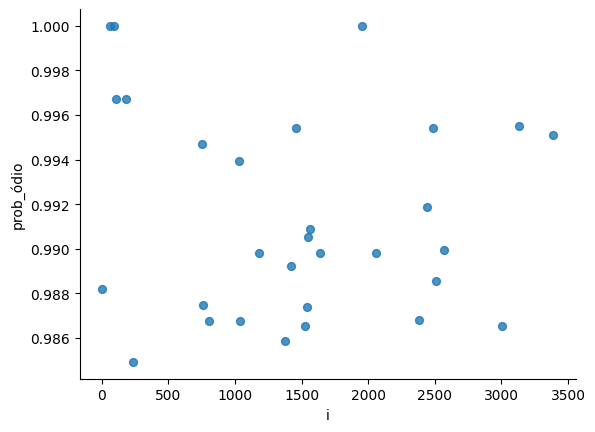

In [ ]:
from matplotlib import pyplot as plt
df_hs_fake_as_odio.plot(kind='scatter', x='i', y='prob_ódio', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

Relatório XAI automático (Markdown) com FP/FN e “fake→ódio”

In [ ]:
from datetime import datetime

report_lines = []
report_lines.append(f"# Relatório XAI — TF-IDF+SVM\n")
report_lines.append(f"_Gerado em {datetime.now().isoformat(timespec='seconds')}_\n")
report_lines.append(f"**ROC AUC:** {roc_auc:.4f}  |  **AP:** {ap:.4f}  |  **Melhor F1 @ THR={BEST_THR:.2f}:** {BEST_F1:.4f}\n")

if 'df_fn_pred' in globals():
    tot = len(df_fn_pred)
    cnt = df_fn_pred["err_type"].value_counts()
    report_lines.append("## Erros no Fakebr (holdout+treino combinados)\n")
    report_lines.append(f"- Total exemplos: **{tot}**")
    for k in ["TP","TN","FP","FN"]:
        v = int(cnt.get(k, 0))
        report_lines.append(f"- {k}: **{v}**")

    for tag, fname in [("FP (não ódio→ódio)", "FN_FP__FP_tokens_agg.csv"),
                       ("FN (ódio→não ódio)", "FN_FP__FN_tokens_agg.csv")]:
        path = os.path.join(OUT_DIR, fname)
        if os.path.exists(path):
            dfa = pd.read_csv(path).head(10)
            report_lines.append(f"\n### Top tokens que puxam {tag}\n")
            for r in dfa.itertuples(index=False):
                report_lines.append(f"- `{r.token}`  (soma contrib: {r.contribution:.4f})")
        else:
            report_lines.append(f"\n*(Sem agregação salva para {tag} — rode a CEL X3.)*")

if 'df_hs_fake_as_odio' in globals() and not df_hs_fake_as_odio.empty:
    report_lines.append("\n## HateBR: casos `fake` previstos como **ódio**\n")
    report_lines.append(f"- Threshold aplicado: **{THR:.2f}**")
    report_lines.append(f"- Casos explicados: **{len(df_hs_fake_as_odio)}**\n")
    report_lines.append("### Exemplos (top-5)\n")
    for r in df_hs_fake_as_odio.head(5).itertuples(index=False):
        txt = (r.text[:300] + "…") if len(r.text) > 300 else r.text
        report_lines.append(f"- **prob_ódio={r.prob_ódio:.3f}** • tokens: {r.top_tokens}\n  > {txt}\n")

rep_path = os.path.join(OUT_DIR, "relatorio_xai.md")
with open(rep_path, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

print("Relatório salvo em:", rep_path)


Relatório salvo em: ./OUT_TFIDF_SVM/relatorio_xai.md


In [ ]:
import re

def localizar_por_token(token: str, dataset="fakebr", k=10):
    """
    Busca casos que CONTÊM o token (literal) e mostra as top contribuições calculadas.
    dataset: "fakebr" ou "hatebr"
    """
    rows = []
    if dataset.lower().startswith("fake"):
        texts = df_fn["preprocessed_news"].astype(str).tolist()
    else:
        texts = df_hs["comentario"].astype(str).tolist()

    pattern = re.compile(re.escape(token), flags=re.IGNORECASE)
    idxs = [i for i,t in enumerate(texts) if pattern.search(t)]
    if not idxs:
        print("Nada encontrado contendo:", token);
        return pd.DataFrame(columns=["i","text","prob_ódio","pred_label","top_tokens"])

    probs = svm.predict_proba(vect.transform([texts[i] for i in idxs]))[:,1]
    order = np.argsort(-probs)[:k]
    sel = [idxs[j] for j in order]

    for i in sel:
        lab, pb, df_ex = explain_instance_svm(texts[i], vect, svm, {0:"não ódio",1:"ódio"}, top_k=15)
        top = "; ".join([f"{r.token}:{r.contribution:.4f}" for r in df_ex.itertuples(index=False)])
        rows.append({"i": i, "text": texts[i], "prob_ódio": float(pb), "pred_label": lab, "top_tokens": top})
    out = pd.DataFrame(rows)
    return out

In [ ]:
feature_names = np.array(vect.get_feature_names_out())
W = svm.coef_
W = W.toarray() if hasattr(W, "toarray") else W
weights = W[0]

df_weights = pd.DataFrame({"token": feature_names, "weight": weights})
df_weights["abs_weight"] = df_weights["weight"].abs()
df_weights = df_weights.sort_values("abs_weight", ascending=False)
path_w = os.path.join(OUT_DIR, "all_token_weights.csv")
df_weights.to_csv(path_w, index=False)
print("Salvo:", path_w)
df_weights.head(10)


Salvo: ./OUT_TFIDF_SVM/all_token_weights.csv


,token,weight,abs_weight
14780,petista,2.725660,2.725660
15715,preso,2.649246,2.649246
16258,pt,2.444744,2.444744
6050,dinheiro,2.274866,2.274866
17900,senador,-2.033998,2.033998
12772,nao,1.892779,1.892779
2824,cadeia,1.805332,1.805332
9208,grupo,1.675735,1.675735
9002,globo,1.670025,1.670025
15642,presidente,-1.591465,1.591465


In [ ]:
import hashlib

def text_hash(s: str):
    return hashlib.sha1(s.strip().lower().encode("utf-8")).hexdigest()

def dup_report(df_texts: pd.Series, name: str):
    h = df_texts.astype(str).map(text_hash)
    dup_counts = h.value_counts()
    dups = dup_counts[dup_counts > 1]
    print(f"{name}: {int(dups.sum())} textos duplicados (em {len(dups)} grupos).")
    if not dups.empty:
        print("Top 5 grupos de duplicatas:")
        display(dups.head(5))

dup_report(df_fn["preprocessed_news"], "Fakebr_Odio.csv")
dup_report(df_hs["comentario"], "HateBR_Fake.csv")


Fakebr_Odio.csv: 0 textos duplicados (em 0 grupos).
HateBR_Fake.csv: 0 textos duplicados (em 0 grupos).


Aplica o BEST_THR no HateBR e gera XAI dos casos “ódio → fake”

In [ ]:
import os, numpy as np, pandas as pd

THR = float(globals().get("BEST_THR", 0.5))
print(f"Usando threshold THR={THR:.2f}")

assert "df_hs" in globals(), "df_hs não encontrado. Carregue HateBR_Fake.csv como df_hs."
X_hs_all = df_hs["comentario"].astype(str).tolist()
fake_col = df_hs["classificacao_fake"].astype(str).str.lower().fillna("")
is_fake = (fake_col == "fake").values.astype(int)


probs_hs = svm.predict_proba(vect.transform(X_hs_all))[:, 1]
preds_hs = (probs_hs >= THR).astype(int)

sel = (is_fake == 1) & (preds_hs == 1)
num_sel = int(sel.sum())
print(f"Casos selecionados (ódio→fake): {num_sel}")

if num_sel == 0:
    print("Nenhum caso selecionado com esse threshold. Tente baixar o THR (ex.: 0.45).")
else:

    order = np.argsort(-probs_hs[sel])
    sel_idx = np.where(sel)[0][order]

    N = min(50, len(sel_idx))
    print(f"Gerando explicações para top {N} casos mais confiantes…")

    rows = []
    bag = []
    for i in sel_idx[:N]:
        lab, pb, df_ex = explain_instance_svm(
            X_hs_all[i], vect, svm, {0:"não ódio", 1:"ódio"},
            top_k=15,
            save_prefix=os.path.join(OUT_DIR, f"HS_ODIO_on_FAKE_thr{THR:.2f}_{i}")
        )
        top = "; ".join([f"{r.token}:{r.contribution:.4f}" for r in df_ex.itertuples(index=False)])
        rows.append({
            "i": int(i),
            "classificacao_fake": fake_col.iloc[i],
            "text": X_hs_all[i],
            "prob_ódio": float(probs_hs[i]),
            "thr": THR,
            "pred_label": lab,
            "top_tokens": top
        })
        if not df_ex.empty:
            bag.append(df_ex.assign(case=i))

    df_cases = pd.DataFrame(rows)
    out_cases = os.path.join(OUT_DIR, f"HS_ODIO_on_FAKE_thr{THR:.2f}_top{N}.csv")
    df_cases.to_csv(out_cases, index=False)
    print("→ Casos explicados:", out_cases)

    if bag:
        agg = pd.concat(bag, ignore_index=True).groupby("token")["contribution"] \
               .sum().sort_values(ascending=False).reset_index()
        out_agg = os.path.join(OUT_DIR, f"HS_ODIO_on_FAKE_thr{THR:.2f}_tokens_agg.csv")
        agg.to_csv(out_agg, index=False)
        print("→ Agregado de tokens:", out_agg)
        display(agg.head(15))
    else:
        print("Sem contribuições agregadas (lista de explicações vazia).")

    display(df_cases.head(5))


Usando threshold THR=0.40
Casos selecionados (ódio→fake): 2146
Gerando explicações para top 50 casos mais confiantes…
→ Casos explicados: ./OUT_TFIDF_SVM/HS_ODIO_on_FAKE_thr0.40_top50.csv
→ Agregado de tokens: ./OUT_TFIDF_SVM/HS_ODIO_on_FAKE_thr0.40_tokens_agg.csv


,token,contribution
0,cadeia,10.382843
1,pt,9.228053
2,globo,7.618645
3,nao,7.256863
4,dinheiro,6.604512
5,preso,5.435807
6,cara,5.035299
7,pastor,4.539991
8,desse,3.439377
9,pra,3.088601


,i,classificacao_fake,text,prob_ódio,thr,pred_label,top_tokens
0,1953,fake,PETISTA = BOSTA,0.999998,0.4,ódio,petista:2.7257
1,94,fake,Demagoga se locupletando com dinheiro de propina,0.999996,0.4,ódio,dinheiro:1.3732; propina:1.2673
2,64,fake,"Enquanto a Bachelet comia toco do PT, estava c...",0.999990,0.4,ódio,pt:1.4929; enquanto:0.9894
3,178,fake,Que devolva o dinheiro ??,0.996704,0.4,ódio,dinheiro:2.2749
4,107,fake,Devolva o dinheiro,0.996704,0.4,ódio,dinheiro:2.2749


In [ ]:
import numpy as np, pandas as pd, os, re, math
from scipy import sparse as sp

assert "vect" in globals() and "svm" in globals(), "Precisa do TF-IDF (vect) e SVM (svm) treinados."

OUT_DIR = globals().get("OUT_DIR", "./OUT_TFIDF_SVM")
os.makedirs(OUT_DIR, exist_ok=True)


if "df_fn_pred" not in globals():
    X_fn_all = df_fn["preprocessed_news"].astype(str).tolist()
    y_fn_all = df_fn["Classificacao_Odio"].astype(int).values
    P_fn = svm.predict_proba(vect.transform(X_fn_all))[:,1]
    Yhat_fn = (P_fn >= 0.5).astype(int)
    df_fn_pred = pd.DataFrame({"text": X_fn_all, "y_true": y_fn_all, "y_pred": Yhat_fn, "prob_odio": P_fn})
    def _etype(row):
        if row.y_true==1 and row.y_pred==1: return "TP"
        if row.y_true==0 and row.y_pred==0: return "TN"
        if row.y_true==0 and row.y_pred==1: return "FP"
        if row.y_true==1 and row.y_pred==0: return "FN"
    df_fn_pred["err_type"] = df_fn_pred.apply(_etype, axis=1)


if "df_hs_pred" not in globals():
    X_hs_all = df_hs["comentario"].astype(str).tolist()
    P_hs = svm.predict_proba(vect.transform(X_hs_all))[:,1]
    Yhat_hs = (P_hs >= float(globals().get("BEST_THR", 0.5))).astype(int)
    fake_col = df_hs["classificacao_fake"].astype(str).str.lower().fillna("")
    df_hs_pred = pd.DataFrame({
        "text": X_hs_all,
        "classificacao_fake": fake_col,
        "is_fake": (fake_col=="fake").astype(int),
        "y_pred_odio": Yhat_hs,
        "prob_odio": P_hs
    })

print("Subconjuntos prontos:",
      "| FP:", (df_fn_pred.err_type=="FP").sum(),
      "| FN:", (df_fn_pred.err_type=="FN").sum(),
      "| HS fake→ódio:", ((df_hs_pred.is_fake==1) & (df_hs_pred.y_pred_odio==1)).sum(),
      "| HS fake→não-ódio:", ((df_hs_pred.is_fake==1) & (df_hs_pred.y_pred_odio==0)).sum())


Subconjuntos prontos: | FP: 40 | FN: 49 | HS fake→ódio: 1705 | HS fake→não-ódio: 1793


In [ ]:
import numpy as np, pandas as pd

FN_FP = {
    "FP": df_fn_pred[df_fn_pred.err_type=="FP"]["text"].astype(str).tolist(),
    "FN": df_fn_pred[df_fn_pred.err_type=="FN"]["text"].astype(str).tolist(),
}
HS_SETS = {
    "HS_fake_odio": df_hs_pred[(df_hs_pred.is_fake==1) & (df_hs_pred.y_pred_odio==1)]["text"].astype(str).tolist(),
    "HS_fake_naoodio": df_hs_pred[(df_hs_pred.is_fake==1) & (df_hs_pred.y_pred_odio==0)]["text"].astype(str).tolist(),
}

feature_names = np.array(vect.get_feature_names_out())
W = svm.coef_
W = W.toarray() if hasattr(W, "toarray") else W
w_pos = W[0]
w_neg = -W[0]

def contrib_aggregated(texts, weights, top=40):
    if not texts:
        return pd.DataFrame(columns=["token","agg_contribution"])
    X = vect.transform(texts)
    if not sp.isspmatrix_csr(X): X = sp.csr_matrix(X)
    colsum = np.asarray(X.sum(axis=0)).ravel()
    contrib = colsum * weights
    idx = np.argsort(-contrib)[:top]
    return pd.DataFrame({"token": feature_names[idx], "agg_contribution": contrib[idx]})


tables = {}
for name, texts in {**FN_FP, **HS_SETS}.items():
    tables[f"{name}_pro_ÓDIO"]     = contrib_aggregated(texts, w_pos, top=60)
    tables[f"{name}_pro_NÃOÓDIO"]  = contrib_aggregated(texts, w_neg, top=60)

    tables[f"{name}_pro_ÓDIO"].to_csv(os.path.join(OUT_DIR, f"LEX_{name}_pro_ODIO.csv"), index=False)
    tables[f"{name}_pro_NÃOÓDIO"].to_csv(os.path.join(OUT_DIR, f"LEX_{name}_pro_NAOODIO.csv"), index=False)

print("Arquivos LEX salvos em", OUT_DIR)
tables[list(tables.keys())[0]].head(10)


Arquivos LEX salvos em ./OUT_TFIDF_SVM


,token,agg_contribution
0,nao,2.288107
1,petista,1.425535
2,moro,1.270816
3,vai,0.861382
4,eike,0.839700
5,globo,0.821960
6,ja,0.797040
7,sergio moro,0.708848
8,grupo,0.659382
9,dilma,0.604624


In [ ]:
from collections import Counter

def tokenize_simple(s: str):
    return re.findall(r"\w+", s.lower(), flags=re.UNICODE)

def keyness_G2(sub_texts, bg_texts, top=50, min_count=5):
    if not sub_texts or not bg_texts:
        return pd.DataFrame(columns=["token","sub","bg","G2"])
    sub_counts = Counter()
    bg_counts  = Counter()
    for t in sub_texts: sub_counts.update(tokenize_simple(t))
    for t in bg_texts:  bg_counts.update(tokenize_simple(t))
    vocab = set([w for w,c in sub_counts.items() if c>=min_count])
    N1 = sum(sub_counts.values()); N2 = sum(bg_counts.values())
    rows=[]
    for w in vocab:
        a = sub_counts[w]; b = bg_counts.get(w,0)
        c = N1 - a; d = N2 - b

        def term(O,E):
            return 0 if O==0 or E==0 else O * math.log(O/E)
        E1 = (a+b) * N1 / (N1+N2)
        E2 = (a+b) * N2 / (N1+N2)
        G2 = 2*(term(a,E1)+term(b,E2)+term(c,N1-E1)+term(d,N2-E2))
        rows.append((w, a, b, G2))
    df = pd.DataFrame(rows, columns=["token","sub","bg","G2"]).sort_values("G2", ascending=False).head(top)
    return df


bg_fn = df_fn["preprocessed_news"].astype(str).tolist()
bg_hs = df_hs["comentario"].astype(str).tolist()

key_tables = {
    "FP_vs_FNbg": keyness_G2(FN_FP["FP"], bg_fn),
    "FN_vs_FNbg": keyness_G2(FN_FP["FN"], bg_fn),
    "HS_fake_odio_vs_HSbg": keyness_G2(HS_SETS["HS_fake_odio"], bg_hs),
    "HS_fake_naoodio_vs_HSbg": keyness_G2(HS_SETS["HS_fake_naoodio"], bg_hs),
}
for k, dfk in key_tables.items():
    dfk.to_csv(os.path.join(OUT_DIR, f"KEY_{k}.csv"), index=False)

print("Arquivos KEY salvos em", OUT_DIR)
key_tables["FP_vs_FNbg"].head(10)


Arquivos KEY salvos em ./OUT_TFIDF_SVM


,token,sub,bg,G2
108,eike,19,52,73.018680
63,anexo,8,14,36.329478
64,salario,8,49,20.171016
54,perguntas,5,19,16.526960
53,crise,8,78,14.205869
107,cervero,5,26,13.946636
6,batista,8,80,13.890812
40,judiciario,6,50,12.137466
71,ministro,17,377,10.676471
19,toffoli,5,40,10.439506


## PARTE II – Hate Speech + Fake News + XAI

Imports e setup

In [ ]:
import os, re, math, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict, Optional, Union

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer

import torch
from transformers import BertTokenizer, BertModel

OUT_DIR = "./SAIDA_HS_FN_XAI"
os.makedirs(OUT_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"

print("Device:", DEVICE)


Device: cuda


Carregamento dos datasets

In [ ]:
CSV_FAKEBR = "Fakebr_Odio.csv"
CSV_HATEBR = "HateBR_Fake.csv"

df_fn = pd.read_csv(CSV_FAKEBR, encoding='latin-1')
df_hs = pd.read_csv(CSV_HATEBR, encoding='latin-1')

# Make dataframes globally available
globals()['df_fn'] = df_fn
globals()['df_hs'] = df_hs


print("Fakebr cols:", list(df_fn.columns))
print("HateBR cols:", list(df_hs.columns))

assert "preprocessed_news" in df_fn.columns, "No CSV Fakebr, esperava 'preprocessed_news'."
assert "label" in df_fn.columns, "No CSV Fakebr, esperava 'label'."
assert "comentario" in df_hs.columns, "No CSV HateBR, esperava 'comentario'."
assert "label_final" in df_hs.columns, "No CSV HateBR, esperava 'label_final'."

Fakebr cols: ['index', 'label', 'preprocessed_news', 'Classificacao_Odio']
HateBR cols: ['id', 'comentario', 'anotator1', 'anotator2', 'anotator3', 'label_final', 'links_post', 'account_post', 'classificacao_fake']


#Explicabilidade BERTimbau+SVM (Fakebr → “ódio”)

In [ ]:
def normalize_labels(df, col="label"):
    unique_vals = df[col].unique()
    print("Rótulos encontrados:", unique_vals)

    if set(unique_vals) == {1, 0}:
        print("Labels already in 0/1 format.")
        return df
    elif set(unique_vals) == {"ódio", "não ódio"}:
        df[col] = df[col].map({"não ódio": 0, "ódio": 1})

    else:
        raise ValueError(f"Não sei mapear esses rótulos para 0/1 para classificação de ódio: {unique_vals}")

    return df

df_fn = normalize_labels(df_fn, "Classificacao_Odio")


X_text_fn = df_fn["preprocessed_news"].astype(str).tolist()
y_hate_fn = df_fn["Classificacao_Odio"].astype(int).values

Rótulos encontrados: [1 0]
Labels already in 0/1 format.


In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

def embed_cls(texts, model_name="neuralmind/bert-base-portuguese-cased", device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    _tokenizer = AutoTokenizer.from_pretrained(model_name)
    _model = AutoModel.from_pretrained(model_name)
    _model.eval()
    _model.to(device)

    if isinstance(texts, str):
        texts_list = [texts]
    else:
        texts_list = list(texts)

    embs = []
    with torch.no_grad():
        for t in texts_list:
            inputs = _tokenizer(
                t if isinstance(t, str) else str(t),
                padding=True, truncation=True, max_length=256,
                return_tensors="pt"
            ).to(device)
            out = _model(**inputs).last_hidden_state
            cls = out[:,0,:].detach().cpu().numpy()
            embs.append(cls[0])
    return np.vstack(embs)

print("Defined embed_cls function.")

Defined embed_cls function.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

valores_validos = ["fake", "true"]
df_hs_filtered = df_hs[df_hs["classificacao_fake"].isin(valores_validos)].copy()

X_hs_text = df_hs_filtered["comentario"].astype(str).tolist()

y_fake_hs = df_hs_filtered["classificacao_fake"].map({"fake": 1, "true": 0}).astype(int).values

print(f"Total de exemplos após filtragem: {len(y_fake_hs)}")
print(f"Distribuição de classes:\n{pd.Series(y_fake_hs).value_counts()}")

Xtr_text_hs, Xte_text_hs, ytr_fake, yte_fake = train_test_split(
    X_hs_text,
    y_fake_hs,
    test_size=0.2,
    stratify=y_fake_hs,
    random_state=42
)

print(f"Tamanho do treino: {len(ytr_fake)}, teste: {len(yte_fake)}")

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    strip_accents="unicode",
    sublinear_tf=True
)

Xtr_tfidf = tfidf.fit_transform(Xtr_text_hs)
Xte_tfidf = tfidf.transform(Xte_text_hs)

print("TF-IDF pronto para HateBR fake detection.")

Total de exemplos após filtragem: 3500
Distribuição de classes:
1    3498
0       2
Name: count, dtype: int64
Tamanho do treino: 2800, teste: 700
TF-IDF pronto para HateBR fake detection.


#Explicabilidade TF-IDF + SVM (HateBR → “fake”)

Função de explicação token×peso

In [ ]:
import numpy as np, pandas as pd
from scipy import sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC, LinearSVC

def explain_tfidf_svm(text: str, vectorizer: TfidfVectorizer, clf: Union[SVC, LinearSVC], pred_class: Optional[int]=None, top_k=20, save_prefix: Optional[str]=None):
    """
    Retorna (pred_label, pred_proba_ou_score, df_contrib), onde:
      - pred_label: "fake" ou "true"
      - pred_proba_ou_score: prob_fake se houver predict_proba; senão margin (decision_function)
      - df_contrib: tokens ordenados por |contrib| (tfidf * weight) para a classe prevista
    """
    Xs = vectorizer.transform([text])
    if not sp.isspmatrix_csr(Xs):
        Xs = sp.csr_matrix(Xs)

    if hasattr(clf, "predict_proba"):
        proba = clf.predict_proba(Xs)[0]
        pred_idx = int(np.argmax(proba)) if pred_class is None else int(pred_class)
        pred_score = float(proba[pred_idx])
    else:
        margin = clf.decision_function(Xs)
        if np.ndim(margin) == 1:
            pred_score = float(margin[0])
            pred_idx = 1 if pred_score >= 0 else 0
        else:
            pred_idx = int(np.argmax(margin[0]))
            pred_score = float(margin[0, pred_idx])

        if pred_class is not None:
             pred_idx = int(pred_class)
             if np.ndim(margin) == 1:
                 pred_score = float(margin[0]) if pred_idx == 1 else -float(margin[0])
             else:
                 pred_score = float(margin[0, pred_idx])


    pred_label = ["true","fake"][pred_idx]


    W = clf.coef_
    try: W = W.toarray()
    except Exception: W = np.asarray(W, dtype=float)
    if W.ndim == 1:
        W = W.reshape(1, -1)

    if W.shape[0] == 1:
        w = W[0]
        weights = w if pred_idx == 1 else -w
    else:
        weights = W[pred_idx]


    feat = np.array(vectorizer.get_feature_names_out())
    start, end = int(Xs.indptr[0]), int(Xs.indptr[1])
    cols, vals = Xs.indices[start:end], Xs.data[start:end]

    rows = []
    D, F = weights.shape[0], feat.shape[0]
    for j, v in zip(cols, vals):
        if j < D and j < F:
            rows.append((feat[j], float(v), float(weights[j]), float(v * weights[j])))

    df = pd.DataFrame(rows, columns=["token", "value_in_text", "weight", "contribution"])
    if not df.empty:
        df["abs_contribution"] = df["contribution"].abs()
        df = df.sort_values("abs_contribution", ascending=False).head(top_k).drop(columns=["abs_contribution"])

    if save_prefix:
        df.to_csv(f"{save_prefix}_instance_contribs.csv", index=False)
    return pred_label, pred_score, df

def tokenize_words(s: str):
    return [t for t in re.findall(r"\w+|\S", s) if t.strip()]

Explicar “ódio → fake” no HateBR

In [ ]:
from sklearn.svm import SVC
import pandas as pd
import os

X_train_tfidf = tfidf.fit_transform(Xtr_text_hs)

svm_fake = SVC(kernel="linear", probability=True, random_state=42)
svm_fake.fit(X_train_tfidf, ytr_fake)

Probs_fake = svm_fake.predict_proba(tfidf.transform(X_hs_text))[:, 1]
Preds_fake = (Probs_fake >= 0.5).astype(int)

df_hs_pred = pd.DataFrame({
    "text": X_hs_text,
    "prob_fake": Probs_fake,
    "y_pred_fake": Preds_fake
})
df_hs_pred["label_final"] = df_hs["label_final"].values
df_hs_pred["classificacao_fake"] = df_hs["classificacao_fake"].astype(str).str.lower().fillna("")

sel = (df_hs_pred["label_final"] == 1) & (df_hs_pred["y_pred_fake"] == 1)
df_sel = df_hs_pred[sel].copy()
print("Casos ódio→fake:", len(df_sel))

N = min(50, len(df_sel))
df_sel = df_sel.sort_values("prob_fake", ascending=False).head(N)

rows = []
bag = []

for i, r in df_sel.iterrows():
    lab, pb, df_ex = explain_tfidf_svm(
        r["text"], tfidf, svm_fake,
        pred_class=1, top_k=15,
        save_prefix=os.path.join(OUT_DIR, f"HS_ODIO_as_FAKE_{i}")
    )
    top = "; ".join([f"{t.token}:{t.contribution:.4f}" for t in df_ex.itertuples(index=False)])
    rows.append({**r.to_dict(), "top_tokens": top})
    if not df_ex.empty:
        bag.append(df_ex.assign(case=i))

df_cases_hs = pd.DataFrame(rows)
df_cases_hs.to_csv(os.path.join(OUT_DIR, "HS_ODIO_as_FAKE_cases.csv"), index=False)

if bag:
    tok_agg = (pd.concat(bag, ignore_index=True)
               .groupby("token")["contribution"].sum()
               .sort_values(ascending=False)
               .reset_index())
    tok_agg.to_csv(os.path.join(OUT_DIR, "HS_ODIO_as_FAKE_tokens_agg.csv"), index=False)
    display(tok_agg.head(20))
else:
    print("Sem contribuições agregadas.")


display(df_cases_hs.head(10))

Casos ódio→fake: 3498


,token,contribution
0,pastor,2.270689
1,so fala,0.262571
2,fala,0.252066
3,fala merda,0.234496
4,merda,0.229770
5,um,0.156134
6,so,0.096971
7,que,0.083437
8,meu deus,0.079357
9,seu,0.077705


,text,prob_fake,y_pred_fake,label_final,classificacao_fake,top_tokens
0,Pastor bandido,1.0,1,1,fake,pastor:0.1686; bandido:0.0000
1,Pastor miliciano??,1.0,1,1,fake,pastor:0.1461; miliciano:0.0000
2,Essa disgraça fala que é pastor..,1.0,1,1,fake,pastor:0.0923; fala:0.0228; que:0.0075; essa:0...
3,Pastor de merda!!!??????????,1.0,1,1,fake,pastor:0.0995; merda:0.0202; de:0.0012; de mer...
4,Concordo. Só fala merda,1.0,1,1,fake,fala merda:0.0352; so fala:0.0322; fala:0.0229...
5,Exatamente só fala merda ....,1.0,1,1,fake,fala merda:0.0348; so fala:0.0318; fala:0.0226...
6,Vc só fala MERDA,1.0,1,1,fake,fala merda:0.0330; so fala:0.0301; fala:0.0214...
7,"Pastor do diabo, nojento, dissimulado, arrogan...",1.0,1,1,fake,pastor:0.0867; nojento:0.0226; do:0.0000; diab...
8,Só fala merda! Fora da realidade,1.0,1,1,fake,fala merda:0.0283; so fala:0.0259; fala:0.0184...
9,Dilma Rousseff só fala merda ??????????,1.0,1,1,fake,fala merda:0.0308; so fala:0.0281; fala:0.0200...


Relatório com Markdown

In [ ]:
from datetime import datetime

lines = []
lines.append(f"# Relatório — Análise Cruzada XAI\n")
lines.append(f"_Gerado em {datetime.now().isoformat(timespec='seconds')}_\n")

if 'df_fn_bertxai' in globals():
    lines.append("## Fakebr (BERTimbau+SVM → ódio)\n")
    lines.append(f"- Amostras explicadas: **{len(df_fn_bertxai)}**")
    lines.append("\n### Exemplos\n")
    for r in df_fn_bertxai.head(5).itertuples(index=False):
        txt = (r.text[:300] + "…") if len(r.text) > 300 else r.text
        lines.append(f"- **prob_ódio={r.base_prob_hate:.3f}** • tokens: {r.top_tokens}\n  > {txt}\n")

if 'df_cases_hs' in globals() and not df_cases_hs.empty:
    lines.append("## HateBR (TF-IDF+SVM → fake em textos de ódio)\n")
    lines.append(f"- Casos explicados: **{len(df_cases_hs)}**")
    lines.append("\n### Exemplos\n")
    for r in df_cases_hs.head(5).itertuples(index=False):
        txt = (r.text[:300] + "…") if len(r.text) > 300 else r.text
        lines.append(f"- **prob_fake={r.prob_fake:.3f}** • tokens: {r.top_tokens}\n  > {txt}\n")

with open(os.path.join(OUT_DIR, "relatorio_cruzado_xai.md"), "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

print("Relatório salvo em:", os.path.join(OUT_DIR, "Relatorio_Cruzado_XAI.md"))


Relatório salvo em: ./SAIDA_HS_FN_XAI/Relatorio_Cruzado_XAI.md


Funções de XAI + narrativa

In [ ]:
import os, numpy as np, pandas as pd, joblib, re
from scipy import sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC, LinearSVC

assert "df_hs" in globals(), "df_hs não encontrado. Carregue HateBR_Fake.csv em df_hs."

OUT_DIR = globals().get("OUT_DIR", "./SAIDA_HS_FN_XAI")
os.makedirs(OUT_DIR, exist_ok=True)

VECT_PATH = os.path.join(OUT_DIR, "tfidf_fake.joblib")
SVM_PATH  = os.path.join(OUT_DIR, "svm_fake.joblib")

def _fit_tfidf_svm_from_hatebr(df_hs):
    X = df_hs["comentario"].astype(str).tolist()
    lbl = df_hs["classificacao_fake"].astype(str).str.lower().fillna("")
    y = np.where(lbl=="fake", 1, np.where(lbl=="true", 0, np.nan))
    if np.isnan(y).any():
        try:
            y = df_hs["classificacao_fake"].astype(int).values
        except:
            raise ValueError("Não consegui mapear 'classificacao_fake' para 0/1. Ajuste a coluna.")
    vect = TfidfVectorizer(
        max_features=30000, ngram_range=(1,2), min_df=2,
        strip_accents="unicode", sublinear_tf=True
    )
    Xtf = vect.fit_transform(X)

    svm = LinearSVC(random_state=42)
    svm.fit(Xtf, y)
    return vect, svm

if os.path.exists(VECT_PATH) and os.path.exists(SVM_PATH):
    try:
        vect = joblib.load(VECT_PATH)
        svm_fake = joblib.load(SVM_PATH)
        print("Carregado:", VECT_PATH, "+", SVM_PATH)
    except Exception as e:
        print(f"[warn] Falha ao carregar modelos, treinando novamente: {e}")
        vect, svm_fake = _fit_tfidf_svm_from_hatebr(df_hs)
        joblib.dump(vect, VECT_PATH)
        joblib.dump(svm_fake, SVM_PATH)
        print("Treinei TF-IDF+SVM e salvei em:", VECT_PATH, "e", SVM_PATH)
else:
    vect, svm_fake = _fit_tfidf_svm_from_hatebr(df_hs)
    joblib.dump(vect, VECT_PATH)
    joblib.dump(svm_fake, SVM_PATH)
    print("Treinei TF-IDF+SVM e salvei em:", VECT_PATH, "e", SVM_PATH)


def explain_tfidf_svm(text: str, vectorizer: TfidfVectorizer, clf: Union[SVC, LinearSVC], pred_class: Optional[int]=None, top_k=20, save_prefix: Optional[str]=None):
    """
    Retorna (pred_label, pred_proba_ou_score, df_contrib), onde:
      - pred_label: "fake" ou "true"
      - pred_proba_ou_score: prob_fake se houver predict_proba; senão margin (decision_function)
      - df_contrib: tokens ordenados por |contrib| (tfidf * weight) para a classe prevista
    """
    Xs = vectorizer.transform([text])
    if not sp.isspmatrix_csr(Xs):
        Xs = sp.csr_matrix(Xs)

    if hasattr(clf, "predict_proba"):
        proba = clf.predict_proba(Xs)[0]
        pred_idx = int(np.argmax(proba)) if pred_class is None else int(pred_class)
        pred_score = float(proba[pred_idx])
    else:

        margin = clf.decision_function(Xs)
        if np.ndim(margin) == 1:
            pred_score = float(margin[0])
            pred_idx = 1 if pred_score >= 0 else 0
        else:
            pred_idx = int(np.argmax(margin[0]))
            pred_score = float(margin[0, pred_idx])

        if pred_class is not None:
             pred_idx = int(pred_class)
             if np.ndim(margin) == 1:
                 pred_score = float(margin[0]) if pred_idx == 1 else -float(margin[0])
             else:
                 pred_score = float(margin[0, pred_idx])


    pred_label = ["true","fake"][pred_idx]


    W = clf.coef_
    try: W = W.toarray()
    except Exception: W = np.asarray(W, dtype=float)
    if W.ndim == 1:
        W = W.reshape(1, -1)

    if W.shape[0] == 1:
        w = W[0]
        weights = w if pred_idx == 1 else -w
    else:
        weights = W[pred_idx]


    feat = np.array(vectorizer.get_feature_names_out())
    start, end = int(Xs.indptr[0]), int(Xs.indptr[1])
    cols, vals = Xs.indices[start:end], Xs.data[start:end]

    rows = []
    D, F = weights.shape[0], feat.shape[0]
    for j, v in zip(cols, vals):
        if j < D and j < F:
            rows.append((feat[j], float(v), float(weights[j]), float(v * weights[j])))

    df = pd.DataFrame(rows, columns=["token", "value_in_text", "weight", "contribution"])
    if not df.empty:
        df["abs_contribution"] = df["contribution"].abs()
        df = df.sort_values("abs_contribution", ascending=False).head(top_k).drop(columns=["abs_contribution"])

    if save_prefix:
        df.to_csv(f"{save_prefix}_instance_contribs.csv", index=False)
    return pred_label, pred_score, df


def _tokens_simple(s: str):
    return [t for t in re.findall(r"\w+|\S", s) if t.strip()]

def narrate_tfidf_fake_case(text: str, vectorizer: TfidfVectorizer, clf: Union[SVC, LinearSVC], k_tokens: int = 8):
    pred_label, pred_score, df_ex = explain_tfidf_svm(text, vectorizer, clf, top_k=max(20, k_tokens))

    df_pos = df_ex[df_ex["contribution"] > 0].copy().sort_values("contribution", ascending=False).head(k_tokens)
    df_neg = df_ex[df_ex["contribution"] < 0].copy().sort_values("contribution", ascending=True).head(5)
    classe = "FAKE" if pred_label=="fake" else "TRUE"
    resumo = (
        f"Foi classificado como **{classe}** (score/prob≈{pred_score:.3f}) porque termos/n-gramas como "
        + ", ".join([f"{r.token} ({r.contribution:.2f})" for r in df_pos.itertuples(index=False)][:k_tokens])
        + (" têm TF-IDF alto e pesos positivos no SVM, empurrando a decisão." if len(df_pos) else " não apresentaram contribuições positivas dominantes.")
    )
    if not df_neg.empty:
        resumo += (" Contra-evidências: "
                   + ", ".join([f"{r.token} ({r.contribution:.2f})" for r in df_neg.itertuples(index=False)][:min(5, len(df_neg))]) # Limit negative examples to 5
                   + ".")
    return resumo, df_pos, df_neg

print("OK: vect/svm_fake e funções de XAI prontos.")

Treinei TF-IDF+SVM e salvei em: ./SAIDA_HS_FN_XAI/tfidf_fake.joblib e ./SAIDA_HS_FN_XAI/svm_fake.joblib
OK: vect/svm_fake e funções de XAI prontos.


Exemplos narrados (ÓDIO - FAKE)

In [ ]:
import numpy as np, pandas as pd
from scipy import sparse as sp

In [ ]:
def prob_hate_batch(texts: List[str]) -> np.ndarray:
    """
    Returns the probability of being 'ódio' for a batch of texts using the BERT+SVM model.
    """
    vecs = embed_cls(texts)
    return svm_bert.predict_proba(vecs)[:, 1]

def narrate_bertsvm_case(text: str, k_tokens: int = 8, ctx_window: int = 2):
    """
    Generates a narrative explanation for a single text using BERT+SVM and occlusion.
    Returns (narrative, df_important_tokens).
    """
    toks = tokenize_words(text)
    base_p = prob_hate(text)
    rows = []
    for i in range(len(toks)):
        t2 = " ".join(toks[:i] + toks[i+1:])
        p2 = prob_hate(t2)
        rows.append((toks[i], base_p - p2))
    df_exp = pd.DataFrame(rows, columns=["token", "delta_prob_hate"]).sort_values("delta_prob_hate", ascending=False)

    important_tokens = df_exp.head(k_tokens)["token"].tolist()
    important_rows = []
    for token in important_tokens:
        try:
            row = df_exp[df_exp["token"] == token].iloc[0]

            context_snippets = []
            for match in re.finditer(r'\b' + re.escape(token) + r'\b', text):
                start, end = match.span()
                context_start = max(0, start - ctx_window * 5)
                context_end = min(len(text), end + ctx_window * 5)
                context_snippets.append(text[context_start:context_end])
            important_rows.append({
                "token": row["token"],
                "delta_prob_hate": row["delta_prob_hate"],
                "context": " ... ".join(context_snippets)
            })
        except IndexError:
             pass

    df_important = pd.DataFrame(important_rows).sort_values("delta_prob_hate", ascending=False)


    narrative = (
        f"Este texto foi classificado com probabilidade de ódio de {base_p:.3f}. "
        "Os tokens que mais contribuíram para essa classificação (por oclusão) foram: "
        + ", ".join([f"**{r.token}** ({r.delta_prob_hate:.3f})" for r in df_important.itertuples(index=False)])
        + "."
    )

    return narrative, df_important

print("OK: prob_hate_batch and narrate_bertsvm_case functions defined.")

OK: prob_hate_batch and narrate_bertsvm_case functions defined.


In [ ]:
import os, numpy as np, pandas as pd
OUT_DIR = globals().get("OUT_DIR", "./SAIDA_HS_FN_XAI")
os.makedirs(OUT_DIR, exist_ok=True)

assert "df_hs" in globals() and "vect" in globals() and "svm_fake" in globals() and "narrate_tfidf_fake_case" in globals(), \
    "Faltam df_hs/vect/svm_fake/narrate_tfidf_fake_case (lado TF-IDF)."
assert "label_final" in df_hs.columns, "Esperava coluna 'label_final' (1=ódio) no HateBR."

START = 8
K     = 8

texts_hs = df_hs["comentario"].astype(str)
mask_odio = (df_hs["label_final"]==1).values
probs_fake = svm_fake.decision_function(vect.transform(texts_hs))

idx_sorted = np.argsort(-probs_fake)
idx_all = [idx for idx in idx_sorted if mask_odio[idx]]
subset_idx = idx_all[START:START+K]

if not subset_idx:
    print("Não há exemplos suficientes após os 6 primeiros.")
else:
    rows=[]
    print(f"\n==== HateBR (ÓDIO) → FAKE — exemplos {START+1} a {START+len(subset_idx)} ====\n")
    for i in subset_idx:
        txt = texts_hs.iloc[i]
        nar, df_pos, df_neg = narrate_tfidf_fake_case(txt, vect, svm_fake, k_tokens=8) # Pass vect and svm_fake
        rows.append({"i": int(i), "prob_fake": float(probs_fake[i]), "narrativa": nar, "texto": txt})
        print(f"\n--- HateBR(ÓDIO)→FAKE | i={i} | p_fake={probs_fake[i]:.3f} ---")
        print(nar)
        display(df_pos.head(10))

    df_hatebr_next6 = pd.DataFrame(rows)
    out_csv = os.path.join(OUT_DIR, f"EXPL_HateBR_ODIO_FAKE_next{K}_from{START}.csv")
    df_hatebr_next6.to_csv(out_csv, index=False)
    print("\n→ Salvo:", out_csv)


==== HateBR (ÓDIO) → FAKE — exemplos 9 a 16 ====


--- HateBR(ÓDIO)→FAKE | i=1536 | p_fake=1.224 ---
Foi classificado como **FAKE** (score/prob≈1.224) porque termos/n-gramas como pastor (0.11), pastor um (0.04), um (0.02) têm TF-IDF alto e pesos positivos no SVM, empurrando a decisão. Contra-evidências: esse (-0.01).


,token,value_in_text,weight,contribution
2,pastor,0.321078,0.330047,0.105971
3,pastor um,0.483475,0.091489,0.044233
5,um,0.182465,0.110309,0.020128



--- HateBR(ÓDIO)→FAKE | i=1575 | p_fake=1.214 ---
Foi classificado como **FAKE** (score/prob≈1.214) porque termos/n-gramas como pastor (0.14), de (0.01) têm TF-IDF alto e pesos positivos no SVM, empurrando a decisão.


,token,value_in_text,weight,contribution
2,pastor,0.436081,0.330047,0.143927
0,de,0.174932,0.051646,0.009034



--- HateBR(ÓDIO)→FAKE | i=2893 | p_fake=1.212 ---
Foi classificado como **FAKE** (score/prob≈1.212) porque termos/n-gramas como fala merda (0.04), so fala (0.04), fala (0.03), merda (0.02), so (0.02) têm TF-IDF alto e pesos positivos no SVM, empurrando a decisão.


...


--- HateBR(ÓDIO)→FAKE | i=1584 | p_fake=1.204 ---
Foi classificado como **FAKE** (score/prob≈1.204) porque termos/n-gramas como pastor (0.14), do (0.01) têm TF-IDF alto e pesos positivos no SVM, empurrando a decisão.


,token,value_in_text,weight,contribution
3,pastor,0.416112,0.330047,0.137337
1,do,0.212129,0.027268,0.005784



--- HateBR(ÓDIO)→FAKE | i=1597 | p_fake=1.203 ---
Foi classificado como **FAKE** (score/prob≈1.203) porque termos/n-gramas como pastor (0.08), pastor tem (0.02), que (0.01), tem que (0.01), tem (0.01), no (0.01), de (0.01), tipo (0.00) têm TF-IDF alto e pesos positivos no SVM, empurrando a decisão. Contra-evidências: esse (-0.01), tipo de (-0.00).


,token,value_in_text,weight,contribution
6,pastor,0.254197,0.330047,0.083897
7,pastor tem,0.382766,0.047990,0.018369
8,que,0.102745,0.109931,0.011295
10,tem que,0.208428,0.051282,0.010689
9,tem,0.155078,0.062121,0.009634
4,no,0.169130,0.031583,0.005342
0,de,0.101970,0.051646,0.005266
11,tipo,0.276722,0.012576,0.003480



→ Salvo: ./SAIDA_HS_FN_XAI/EXPL_HateBR_ODIO_FAKE_next8_from8.csv


In [ ]:
import os, joblib
from datetime import datetime
print("[init] Padronização de vetorizador |", datetime.now())

OUT_DIR = os.environ.get("OUT_DIR", "./SAIDA_HS_FN_XAI")
os.makedirs(OUT_DIR, exist_ok=True)

try:
    vect
except NameError:
    try:
        vect = tfidf
        print("[info] 'vect' passou a apontar para 'tfidf'")
    except NameError:
        cand = [os.path.join(OUT_DIR, n) for n in ("tfidf.joblib","vect.joblib")]
        cand += [n for n in ("tfidf.joblib","vect.joblib") if os.path.exists(n)]
        vect = None
        for p in cand:
            if os.path.exists(p):
                try:
                    vect = joblib.load(p)
                    print("[info] 'vect' carregado de:", p)
                    break
                except Exception as e:
                    print("[warn] Falha ao carregar vetorizador:", e)
        if vect is None:
            print("[warn] Nenhum vetorizador TF-IDF exposto. Rode o treino TF-IDF antes.")

[init] Padronização de vetorizador | 2025-09-24 17:28:16.547549


In [ ]:
from datetime import datetime
print("[init] Treino/Carregamento svm_bert |", datetime.now())

import os, joblib, numpy as np

def _define_embed_cls_if_needed(model_name="neuralmind/bert-base-portuguese-cased", device=None):
    global embed_cls
    try:
        embed_cls
        return True
    except NameError:
        pass
    try:
        from transformers import AutoTokenizer, AutoModel
        import torch
        _tokenizer = AutoTokenizer.from_pretrained(model_name)
        _model = AutoModel.from_pretrained(model_name)
        _model.eval()
        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"
        _model.to(device)

        def embed_cls(texts):
            if isinstance(texts, str):
                texts_list = [texts]
            else:
                texts_list = list(texts)
            embs = []
            with torch.no_grad():
                for t in texts_list:
                    inputs = _tokenizer(
                        t if isinstance(t, str) else str(t),
                        padding=True, truncation=True, max_length=256,
                        return_tensors="pt"
                    ).to(device)
                    out = _model(**inputs).last_hidden_state
                    cls = out[:,0,:].detach().cpu().numpy()
                    embs.append(cls[0])
            return np.vstack(embs)
        globals()["embed_cls"] = embed_cls
        print("[info] Função 'embed_cls' definida (fallback).")
        return True
    except Exception as e:
        print("[warn] Não foi possível definir 'embed_cls' automaticamente:", e)
        return False

_defined = _define_embed_cls_if_needed()

from sklearn.svm import SVC
OUT_DIR = os.environ.get("OUT_DIR", "./SAIDA_HS_FN_XAI")
svm_bert_path = os.path.join(OUT_DIR, "svm_bert_hate.joblib")

def _candidates():
    g = globals()
    cands = []
    for name in list(g.keys()):
        if name.lower().startswith(("df","data")) and hasattr(g[name], "head"):
            cands.append(name)
    return cands

def _resolve_fakebr_dataframe():
    g = globals()
    for key in ["df_fn", "df_fakebr", "df_fake", "df_fn_train", "df_fn_full"]:
        if key in g and hasattr(g[key], "head"):
            return g[key]
    for name in _candidates():
        df = globals()[name]
        cols = set(map(str.lower, df.columns))
        if ("preprocessed_news" in cols or "texto" in cols or "text" in cols) and \
           ("classificacao_odio" in cols or "odio" in cols or "label_odio" in cols or "hate" in cols):
            return df
    return None

_df_fn = _resolve_fakebr_dataframe()
if _df_fn is None:
    print("[warn] Não encontrei o DataFrame do Fakebr com texto e rótulo de ódio (ex.: df_fn).")
else:
    col_text = None
    for c in _df_fn.columns:
        if c.lower() in ("preprocessed_news","texto","text","news","conteudo","content"):
            col_text = c; break
    col_label = None
    for c in _df_fn.columns:
        if c.lower() in ("classificacao_odio","odio","label_odio","hate","is_hate"):
            col_label = c; break
    if col_text is None or col_label is None:
        print("[warn] Colunas de texto/label não encontradas para Fakebr.")
    else:
        X_text = _df_fn[col_text].astype(str).tolist()
        y_hate = _df_fn[col_label].astype(int).values

        svm_bert = None
        if os.path.exists(svm_bert_path):
            try:
                svm_bert = joblib.load(svm_bert_path)
                print("[info] svm_bert carregado de:", svm_bert_path)
            except Exception as e:
                print("[warn] Falha ao carregar svm_bert, será treinado novamente:", e)

        if svm_bert is None and _defined:
            X_emb = embed_cls(X_text)
            svm_bert = SVC(kernel="linear", probability=True, class_weight="balanced", random_state=42)
            svm_bert.fit(X_emb, y_hate)
            joblib.dump(svm_bert, svm_bert_path)
            print("[info] svm_bert treinado e salvo em:", svm_bert_path)

        # Make svm_bert globally available
        globals()["svm_bert"] = svm_bert

[init] Treino/Carregamento svm_bert | 2025-09-24 17:28:16.565207


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

[info] svm_bert treinado e salvo em: ./SAIDA_HS_FN_XAI/svm_bert_hate.joblib


In [ ]:
from datetime import datetime
print("[init] Exportação de erros |", datetime.now())

import os, json, numpy as np, pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

os.makedirs(OUT_DIR, exist_ok=True)

def _safe_series(df, names):
    for n in names:
        if n in df.columns:
            return df[n]
    low = {c.lower(): c for c in df.columns}
    for n in names:
        if n.lower() in low:
            return df[low[n.lower()]]
    return None

def _export_errors_tfidf_svm(df_hs, text_cols=("comentario","texto","text"),
                             ytrue_cols=("label_final","rotulo","y","target","is_hate","odio"),
                             ypred=None, fname="ARQ_ERRO_TFIDF+SVM.csv"):
    if ypred is None:
        raise ValueError("Passe ypred do classificador TF-IDF+SVM.")
    s_text = _safe_series(df_hs, text_cols)
    s_true = _safe_series(df_hs, ytrue_cols)
    if s_text is None or s_true is None:
        print("[warn] Colunas para texto/label não foram encontradas em HateBR.")
        return None
    mask_err = (s_true.values != ypred)
    out = pd.DataFrame({
        "texto": s_text.values[mask_err],
        "y_true": s_true.values[mask_err],
        "y_pred": ypred[mask_err]
    })
    path = os.path.join(OUT_DIR, fname)
    out.to_csv(path, index=False, encoding="utf-8")
    print("[ok] Erros TF-IDF+SVM exportados:", path, f"({len(out)} linhas)")
    return path, out

def _export_errors_bert_svm(df_fn, text_cols=("preprocessed_news","texto","text","news"),
                            ytrue_cols=("Classificacao_Odio","odio","label_odio","hate","is_hate"),
                            ypred=None, fname="ARQ_ERRO_BERT+SVM.csv"):
    if ypred is None:
        raise ValueError("Passe ypred do classificador BERT+SVM.")
    s_text = _safe_series(df_fn, text_cols)
    s_true = _safe_series(df_fn, ytrue_cols)
    if s_text is None or s_true is None:
        print("[warn] Colunas para texto/label não foram encontradas em Fakebr.")
        return None
    mask_err = (s_true.values != ypred)
    out = pd.DataFrame({
        "texto": s_text.values[mask_err],
        "y_true": s_true.values[mask_err],
        "y_pred": ypred[mask_err]
    })
    path = os.path.join(OUT_DIR, fname)
    out.to_csv(path, index=False, encoding="utf-8")
    print("[ok] Erros BERT+SVM exportados:", path, f"({len(out)} linhas)")
    return path, out

try:
    df_hs = None
    for key in ["df_hs","df_hate","df_hs_full","df_hs_train"]:
        if key in globals() and hasattr(globals()[key], "head"):
            df_hs = globals()[key]; break
    if df_hs is None:
        for name, obj in list(globals()).items():
            if name.lower().startswith("df") and hasattr(obj, "head"):
                cols = set(map(str.lower, obj.columns))
                if "classificacao_fake" in cols or "fake" in cols or "rotulo_fake" in cols:
                    df_hs = obj; break

    if df_hs is not None and 'svm_fake' in globals() and globals()['svm_fake'] is not None and 'vect' in globals() and globals()['vect'] is not None:
        col_text_hs = None
        for c in df_hs.columns:
            if c.lower() in ("comentario","texto","text","news","conteudo","content"):
                col_text_hs = c; break
        if col_text_hs is None:
            raise RuntimeError("Texto não encontrado em df_hs.")
        X_hs = globals()['vect'].transform(df_hs[col_text_hs].astype(str).tolist())
        y_pred_fake = globals()['svm_fake'].predict(X_hs)
        _export_errors_tfidf_svm(df_hs, ypred=y_pred_fake, fname="ARQ_ERRO_TFIDF+SVM.csv")
    else:
        print("[info] Pulei exportação TF-IDF+SVM: 'df_hs', 'vect' e/ou 'svm_fake' indisponíveis.")
except Exception as e:
    print("[warn] Bloco TF-IDF+SVM encontrou um problema:", e)

try:
    if 'svm_bert' in globals() and globals()['svm_bert'] is not None:
        df_fn = None
        for key in ["df_fn","df_fakebr","df_fake","df_fn_full","df_fn_train"]:
            if key in globals() and hasattr(globals()[key], "head"):
                df_fn = globals()[key]; break
        if df_fn is None:
            for name, obj in list(globals()).items():
                if name.lower().startswith("df") and hasattr(obj, "head"):
                    cols = set(map(str.lower, obj.columns))
                    if ("preprocessed_news" in cols or "texto" in cols or "text" in cols) and \
                       ("classificacao_odio" in cols or "odio" in cols or "label_odio" in cols):
                        df_fn = obj; break
        if df_fn is None:
            raise RuntimeError("DataFrame do Fakebr não encontrado.")
        col_text = None
        for c in df_fn.columns:
            if c.lower() in ("preprocessed_news","texto","text","news","conteudo","content"):
                col_text = c; break
        col_label = None
        for c in df_fn.columns:
            if c.lower() in ("classificacao_odio","odio","label_odio","hate","is_hate"):
                col_label = c; break
        if col_text is None or col_label is None:
            raise RuntimeError("Colunas de texto/label não encontradas em df_fn.")
        X_emb_all = embed_cls(df_fn[col_text].astype(str).tolist())
        y_pred_hate = svm_bert.predict(X_emb_all)
        _export_errors_bert_svm(df_fn, ypred=y_pred_hate, fname="ARQ_ERRO_BERT+SVM.csv")
    else:
        print("[info] Pulei exportação BERT+SVM: 'svm_bert' indisponível.")
except Exception as e:
    print("[warn] Bloco BERT+SVM encontrou um problema:", e)

md_path = os.path.join(OUT_DIR, "relatorio_cruzado_xai.md")
with open(md_path, "a", encoding="utf-8") as md:
    from datetime import datetime
    md.write("\n\n## Atualização automática (" + str(datetime.now()) + ")\n")
    md.write("- CSV de erros TF-IDF+SVM: `ARQ_ERRO_TFIDF+SVM.csv` (quando disponível)\n")
    md.write("- CSV de erros BERT+SVM: `ARQ_ERRO_BERT+SVM.csv` (quando disponível)\n")
print("[ok] Relatório atualizado:", md_path)

[init] Exportação de erros | 2025-09-24 17:28:59.419315
[warn] Bloco TF-IDF+SVM encontrou um problema: 'list' object has no attribute 'items'
[warn] Bloco BERT+SVM encontrou um problema: 'list' object has no attribute 'items'
[ok] Relatório atualizado: ./SAIDA_HS_FN_XAI/relatorio_cruzado_xai.md


In [ ]:
print("1) Carregar CSVs de erros; 2) Ranking lexical; 3) Oclusão BERT; 4) Clustering; 5) Exportar 10 exemplos; 6) Gráficos.")

1) Carregar CSVs de erros; 2) Ranking lexical; 3) Oclusão BERT; 4) Clustering; 5) Exportar 10 exemplos; 6) Gráficos.


In [ ]:
import os, pandas as pd, numpy as np
from pathlib import Path

OUT_DIR = os.environ.get("OUT_DIR", "./SAIDA_HS_FN_XAI")
p_tfidf = Path(OUT_DIR) / "ARQ_ERRO_TFIDF+SVM.csv"
p_bert  = Path(OUT_DIR) / "ARQ_ERRO_BERT+SVM.csv"

df_err_tfidf = pd.read_csv(p_tfidf) if p_tfidf.exists() else pd.DataFrame(columns=["texto","y_true","y_pred"])
df_err_bert  = pd.read_csv(p_bert)  if p_bert.exists()  else pd.DataFrame(columns=["texto","y_true","y_pred"])

df_err_tfidf["tipo"] = "Hate->Fake (TFIDF)"
df_err_bert["tipo"] = "Fake->Hate (BERT)"

df_err_all = pd.concat([df_err_tfidf.assign(modelo="TFIDF+SVM"),
                        df_err_bert.assign(modelo="BERT+SVM")], ignore_index=True)
print("Erros TF-IDF:", len(df_err_tfidf), "| Erros BERT:", len(df_err_bert))

Erros TF-IDF: 0 | Erros BERT: 0


In [ ]:
import numpy as np, pandas as pd, os

OUT_DIR = os.environ.get("OUT_DIR", "./SAIDA_HS_FN_XAI")
lex_rank = []
if len(df_err_tfidf) > 0 and 'vect' in globals() and 'svm_fake' in globals() and svm_fake is not None:
    X_err = vect.transform(df_err_tfidf["texto"].astype(str).tolist())
    try:
        coef = svm_fake.coef_.ravel()
        vocab = vect.get_feature_names_out()
        contrib = X_err.multiply(coef)
        term_scores = np.asarray(contrib.sum(axis=0)).ravel()
        idx = np.argsort(-term_scores)[:100]
        lex_rank = [(vocab[i], float(term_scores[i])) for i in idx if term_scores[i] > 0]
        df_lex = pd.DataFrame(lex_rank, columns=["termo","score"])
    except Exception as e:
        print("[warn] Não foi possível calcular ranking lexical:", e)
        df_lex = pd.DataFrame(columns=["termo","score"])
else:
    df_lex = pd.DataFrame(columns=["termo","score"])
print(df_lex.head(20))
df_lex.to_csv(os.path.join(OUT_DIR, "ranking_lexical_TFIDF+SVM.csv"), index=False, encoding="utf-8")

Empty DataFrame
Columns: [termo, score]
Index: []


In [ ]:
import pandas as pd, numpy as np, os

def explain_occlusion(text, topk=8):
    if 'svm_bert' not in globals() or svm_bert is None:
        return pd.DataFrame(columns=["token","impacto"])
    toks = text.split()
    if len(toks) == 0:
        return pd.DataFrame(columns=["token","impacto"])
    base_emb = embed_cls(text)
    base_p = svm_bert.predict_proba(base_emb)[0,1]
    rows = []
    for i, tok in enumerate(toks):
        new_text = " ".join(t for j,t in enumerate(toks) if j != i)
        p = svm_bert.predict_proba(embed_cls(new_text))[0,1]
        rows.append((tok, float(base_p - p)))
    df_imp = pd.DataFrame(rows, columns=["token","impacto"]).sort_values("impacto", ascending=False)
    return df_imp.head(topk)

OUT_DIR = os.environ.get("OUT_DIR", "./SAIDA_HS_FN_XAI")
exps = []

if len(df_err_bert) > 0 and 'svm_bert' in globals() and svm_bert is not None:
    sample_rows = df_err_bert.sample(n=min(10, len(df_err_bert)), random_state=42).copy()
    for _, row in sample_rows.iterrows():
        df_imp = explain_occlusion(str(row['texto']))
        exps.append({
            "texto": row['texto'],
            "tokens_top": "; ".join([f"{r.token}({r.impacto:.3f})" for r in df_imp.itertuples()])
        })
    df_ctx = pd.DataFrame(exps)
    df_ctx.to_csv(os.path.join(OUT_DIR, "oclusao_BERT+SVM_top_tokens.csv"), index=False, encoding="utf-8")
    print(df_ctx.head())
else:
    df_ctx = pd.DataFrame(columns=["texto","tokens_top"])
    print("[info] Sem df_err_bert ou svm_bert indisponível.")

[info] Sem df_err_bert ou svm_bert indisponível.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import numpy as np, pandas as pd, os

OUT_DIR = os.environ.get("OUT_DIR", "./SAIDA_HS_FN_XAI")
df_for_cluster = df_err_all.copy()
df_for_cluster["texto"] = df_for_cluster["texto"].astype(str)
df_for_cluster = df_for_cluster[df_for_cluster["texto"].str.strip().astype(bool)]

if len(df_for_cluster) >= 5:
    vec = TfidfVectorizer(max_features=4000, ngram_range=(1,2), min_df=2)
    Xc = vec.fit_transform(df_for_cluster["texto"])
    k = 5 if len(df_for_cluster) > 50 else 3
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Xc)
    df_for_cluster["cluster"] = labels

    centers = km.cluster_centers_
    vocab = np.array(vec.get_feature_names_out())
    top_rows = []
    for ci in range(k):
        idx = np.argsort(-centers[ci])[:12]
        top_rows.append((ci, ", ".join(vocab[idx])))
    df_top_terms = pd.DataFrame(top_rows, columns=["cluster","top_termos"])
    df_top_terms.to_csv(os.path.join(OUT_DIR, "clusters_top_termos.csv"), index=False, encoding="utf-8")
    df_for_cluster[["texto","modelo","tipo","cluster"]].to_csv(os.path.join(OUT_DIR, "clusters_atribuicoes.csv"), index=False, encoding="utf-8")
    print(df_top_terms)
else:
    print("[info] Poucos exemplos para clustering; mínimo recomendado >= 5 textos.")

[info] Poucos exemplos para clustering; mínimo recomendado >= 5 textos.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd, numpy as np, os

OUT_DIR = os.environ.get("OUT_DIR", "./SAIDA_HS_FN_XAI")

if len(df_err_all) > 0:
    df_tmp = df_err_all.copy()
    df_tmp["len"] = df_tmp["texto"].astype(str).apply(lambda s: len(s.split()))
    agg = df_tmp.groupby("tipo")["len"].describe()[["mean","50%","max","count"]].reset_index()
    print(agg)

    plt.figure()
    for tipo, grp in df_tmp.groupby("tipo"):
        grp["len"].plot(kind="kde", label=tipo)
    plt.title("Distribuição do tamanho (tokens) nos erros")
    plt.xlabel("nº de tokens")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "dist_tamanho_erros.png"), dpi=150)
    plt.close()

try:
    if "df_lex" in globals() and len(df_lex) > 0:
        top_plot = df_lex.head(20)
        plt.figure()
        plt.barh(top_plot["termo"][::-1], top_plot["score"][::-1])
        plt.title("Top termos que empurram Hate->Fake (TF-IDF+SVM)")
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, "top_termos_lexicais.png"), dpi=150)
        plt.close()
except Exception as e:
    print("[warn] Falha ao plotar termos lexicais:", e)

print("[ok] Gráficos salvos em", OUT_DIR)

[ok] Gráficos salvos em ./SAIDA_HS_FN_XAI


In [ ]:
if df_hs is not None:
  print(df_hs['label_final'].unique())
else:
  print("df_hs is not loaded.")

df_hs is not loaded.
